# About Dataset
The data consists of 48x48 pixel grayscale images of faces. The faces have been automatically registered so that the face is more or less centred and occupies about the same amount of space in each image.

The task is to categorize each face based on the emotion shown in the facial expression into one of seven categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral). The training set consists of 28,709 examples and the public test set consists of 3,589 Private Samples and 3,589 Public Sample.

# Imports

In [118]:
import os
import glob as gb
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical



from tensorflow.keras.applications.vgg16 import VGG16

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [119]:
import warnings
warnings.filterwarnings('ignore')

# Reading Images

In [288]:
classes = {'angry': 0,
           'disgust': 1,
           'fear': 2,
           'happy':3,
           'neutral':4,
           'sad':5,
           'surprise':6}

img_dim = 48

classes_list = list(classes.keys())

In [121]:
# Reading Images and Labeling them
def read_image_from_path(path, img_dim, gray_scale=False, Validation=False):
    X = []
    y = []

    # Reading Folders
    for folder in os.listdir(path):
        # Reading Images in Folders
        files = gb.glob(pathname=str(path + '/' + folder + '/*jpg')) 
        for file in files:
          if gray_scale:
            image = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
          else:
            image = cv2.imread(file)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

          image_array = cv2.resize(image, (img_dim, img_dim))
          X.append(list(image))
          y.append(classes[folder])

    X = np.array(X)
    y = np.array(y)
    
    # Splitting data
    if Validation:
        X_train, X_validate, y_train, y_validate = train_test_split(X, y, test_size=0.25, random_state=2)
        return X_train, X_validate, y_train, y_validate
    
    return X, y

In [122]:
X_train, X_validate, y_train, y_validate = read_image_from_path('/kaggle/input/fer2013/train', img_dim, True, True)
X_test, y_test = read_image_from_path('/kaggle/input/fer2013/test', img_dim, True)

In [123]:
X_train.shape, X_test.shape,X_validate.shape

((21531, 48, 48), (7178, 48, 48), (7178, 48, 48))

In [124]:
y_train.shape, y_test.shape,y_validate.shape

((21531,), (7178,), (7178,))

# Exploring Data

In [125]:
# Count each emotion and turn it into dataframe
def count_classes(y):
  count = []
  for i in y:
      if i == 0:
        count.append('angry 😡')
      elif i == 1:
        count.append('disgust 🤢')
      elif i == 2:
        count.append('fear 😨')
      elif i == 3:
        count.append('happy 😁')
      elif i == 4:
        count.append('neutral 😐')
      elif i == 5:
        count.append('sad 😭')
      else:
        count.append('surprise 😳')

  count_df = pd.DataFrame(count, columns=['Emotions'])
  return count_df

# Visualize the Y to Get its Distrbution
def visualize_count(y, name):
  count_df = count_classes(y)

  emotion_order = count_df['Emotions'].value_counts().sort_values(ascending=False).index

  sns.set_style(style='whitegrid')

  plt.figure(figsize=(10, 5))
  sns.countplot(data = count_df, x='Emotions', palette='viridis', order=emotion_order)
  plt.xlabel('Emotions', color = 'black', fontsize=12)
  plt.xticks(color = 'black')
  plt.ylabel('Frequency', color = 'black', fontsize=12)
  plt.yticks(color = 'black')
  plt.title(f'{name} Images Distribution', color = 'black', fontweight='bold', fontsize=15)
  plt.show()

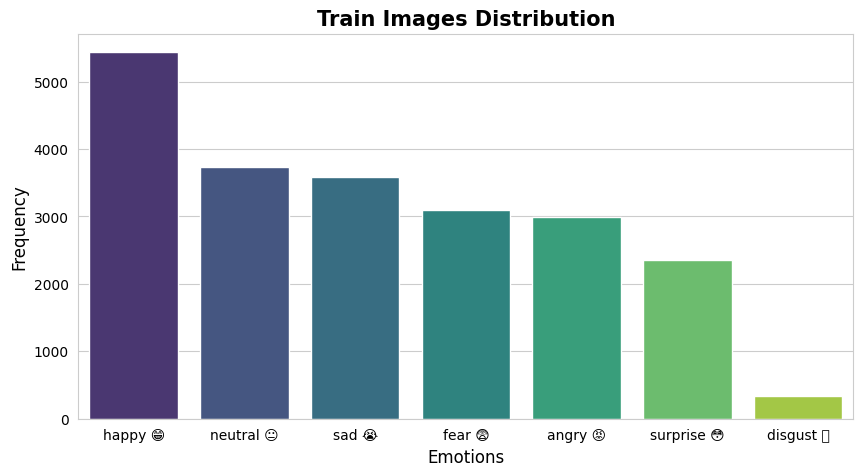

In [126]:
visualize_count(y_train, 'Train')

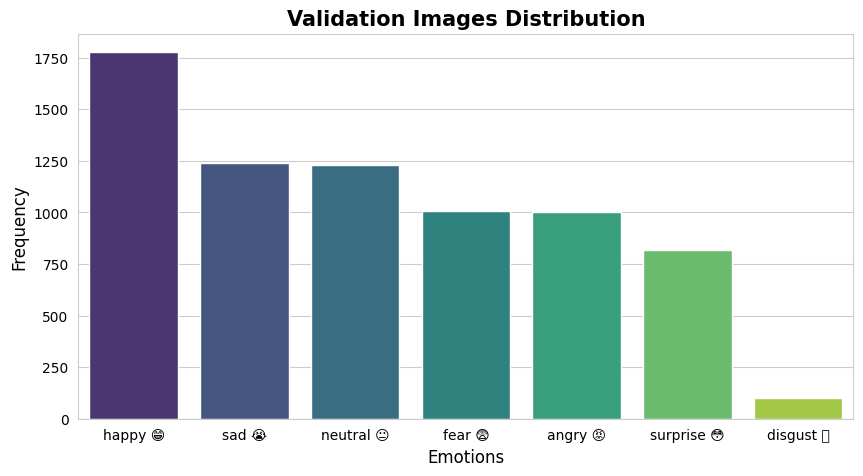

In [127]:
visualize_count(y_validate, 'Validation')

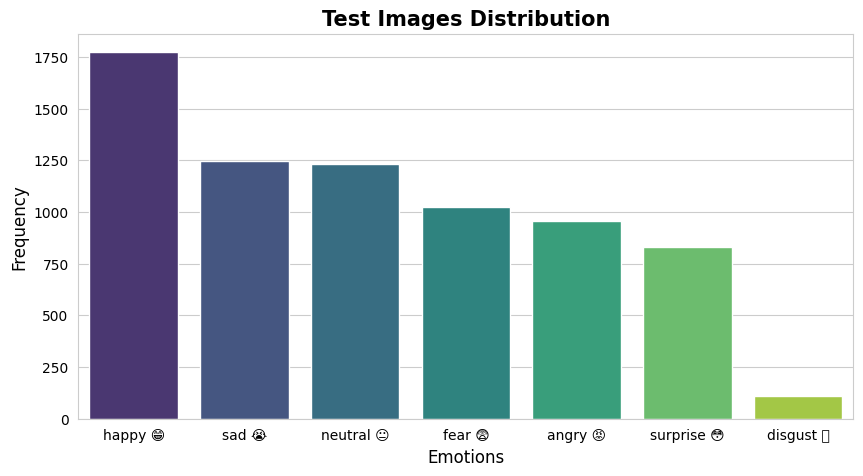

In [128]:
visualize_count(y_test, 'Test')

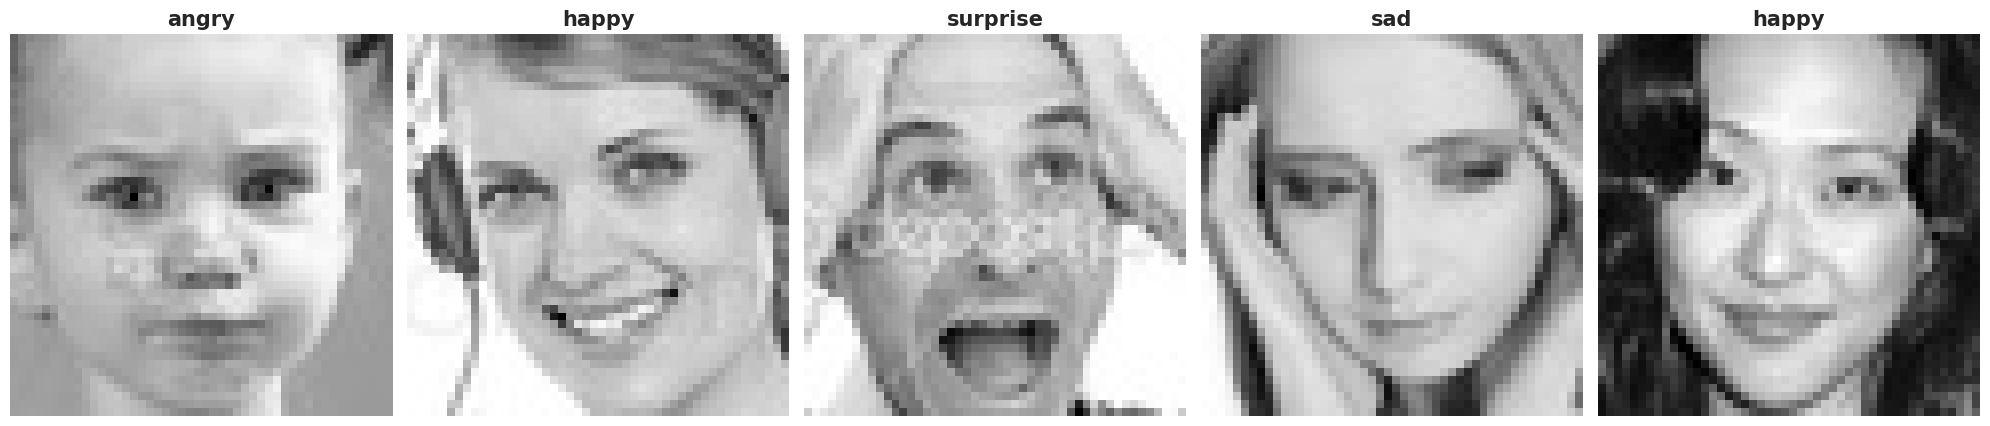

In [129]:
plt.figure(figsize=(20, 10))

for i in range(10):
  img_no = np.random.randint(0, X_train.shape[0])
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[img_no], cmap='gray')
  plt.axis('off')
  plt.title(classes_list[y_train[img_no]], fontsize = 15, fontweight='bold')
  plt.tight_layout()
  plt.grid(False)
plt.show()

# Data preprocessing

In [130]:
# Normalization
X_train = X_train / 255
X_validate = X_validate / 255
X_test = X_test / 255

In [131]:
# Changes how the array is organized in memory
X_train = X_train.reshape(-1, img_dim, img_dim, 1)
X_validate = X_validate.reshape(-1, img_dim, img_dim, 1)
X_test = X_test.reshape(-1, img_dim, img_dim, 1)

In [132]:
# Turning to Categorical Features using Tensorflow
y_train = to_categorical(y_train, num_classes=7)
y_validate = to_categorical(y_validate, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

### Data Augmentation

In [133]:
train_datagen = ImageDataGenerator(
    width_shift_range=0.1,     # Slight horizontal shifts
    height_shift_range=0.1,    # Slight vertical shifts
    horizontal_flip=True,      # Faces can appear mirrored
)

# Create data generators
train_generator = train_datagen.flow(X_train, y_train, batch_size=64)

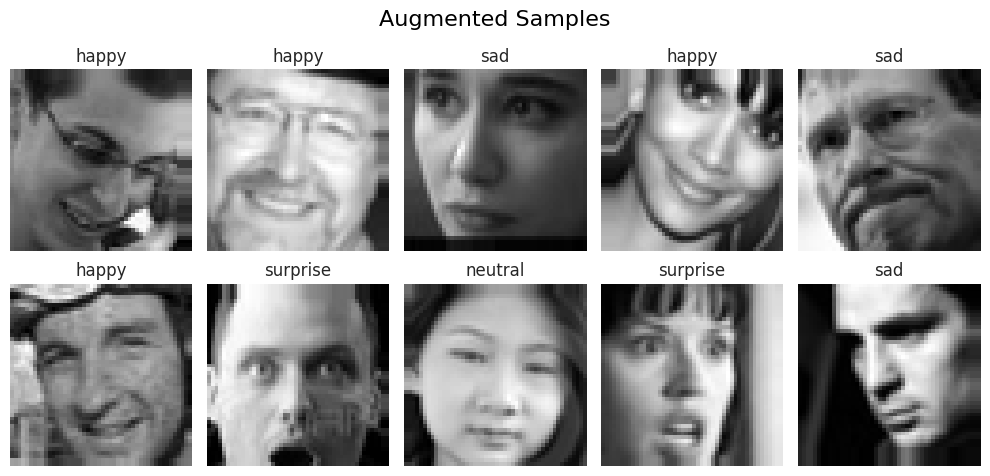

In [134]:
# Visualizing Augmented Samples
images, labels = next(train_generator)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(classes_list[np.argmax(labels[i])])
    plt.axis('off')
plt.suptitle('Augmented Samples', fontsize=16, color='black')
plt.tight_layout()
plt.show()

# Model (Custom Made)

In [170]:
model = Sequential()

# CNN First Layer
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape = (img_dim, img_dim, 1)))
model.add(BatchNormalization())


# CNN Second Layer
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# CNN Third Layer
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# CNN Fourth Layer
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Dropout(0.25))

# CNN Fifth Layer
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))

# CNN Sixth Layer
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Dropout(0.25))

# CNN Seventh Layer
model.add(Conv2D(512, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2))
model.add(Dropout(0.25))

#Flatten Layer
model.add(Flatten())

# Dense First Layer
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Dense Second Layer
model.add(Dense(256, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(7, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_43               │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_44               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_39 (Dropout)                 │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_45               │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_40 (Dropout)                 │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_46               │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_41 (Dropout)                 │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_47               │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_42 (Dropout)                 │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_48               │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 4,807,175 (18.34 MB)

 Trainable params: 4,802,887 (18.32 MB)

 Non-trainable params: 4,288 (16.75 KB)

In [171]:
# Callbacks
early_stoping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Training

In [172]:
history = model.fit(train_generator,
                    epochs = 60,
                    validation_data = (X_validate, y_validate),
                    callbacks = [early_stoping])

Epoch 1/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.1907 - loss: 2.5486 - val_accuracy: 0.1904 - val_loss: 1.9913
Epoch 2/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.2924 - loss: 1.8512 - val_accuracy: 0.3550 - val_loss: 1.6467
Epoch 3/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3819 - loss: 1.5832 - val_accuracy: 0.4561 - val_loss: 1.4152
Epoch 4/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.4527 - loss: 1.4248 - val_accuracy: 0.5046 - val_loss: 1.3024
Epoch 5/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4924 - loss: 1.3255 - val_accuracy: 0.5099 - val_loss: 1.3092
Epoch 6/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5138 - loss: 1.2603 - val_accuracy: 0.5411 - val_loss: 1.2014
Epoch 7/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5416 - loss: 1.2143 - val_accuracy: 0.5219 - val_loss: 1.2687
Epoch 8/60
337/337 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5473 - loss: 1.1867 - val_acc

# Evaluating


In [173]:
model_eval = model.evaluate(X_test, y_test)
print("Loss of Model: ", model_eval[0])
print("Accuracy of Model:", round(model_eval[1]*100,2),'%')

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6534 - loss: 0.9829
Loss of Model:  0.9361973404884338
Accuracy of Model: 66.65 %


In [174]:
model_eval = model.evaluate(X_train, y_train)
print("Loss of Model: ", model_eval[0])
print("Accuracy of Model:", round(model_eval[1]*100,2),'%')

673/673 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7874 - loss: 0.5892
Loss of Model:  0.5879138708114624
Accuracy of Model: 78.44 %


## Loss & Accuracy Graph

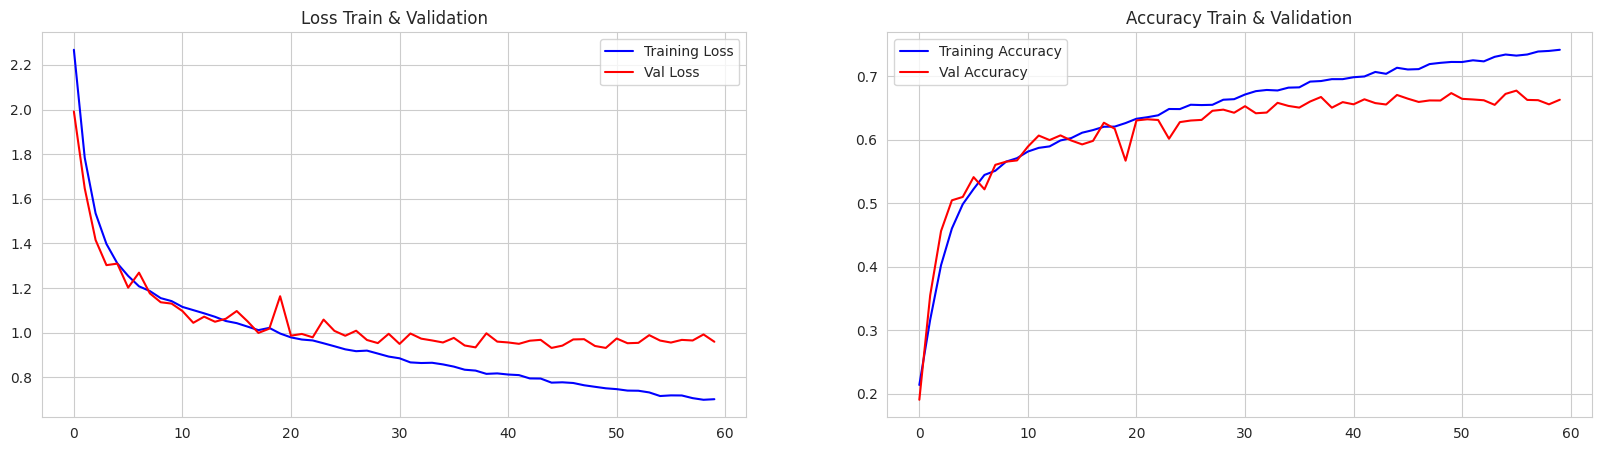

In [175]:
plt.figure(figsize = (20,5))

plt.subplot(1,2,1)
sns.lineplot(x=history.epoch, y=history.history['loss'], color='blue', label='Training Loss')
sns.lineplot(x=history.epoch, y=history.history['val_loss'], color='red', label='Val Loss')
plt.title('Loss Train & Validation')
plt.legend(loc='best')

plt.subplot(1,2,2)
sns.lineplot(x=history.epoch, y=history.history['accuracy'], color='blue', label='Training Accuracy')
sns.lineplot(x=history.epoch, y=history.history['val_accuracy'], color='red', label='Val Accuracy')
plt.title('Accuracy Train & Validation')
plt.legend(loc='best')

plt.show()

## Classification Report 

In [176]:
predicitions = model.predict(X_test)

y_test_int = np.argmax(y_test, axis=1)
predicitions = np.argmax(predicitions, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [177]:
print(classification_report(y_test_int, predicitions, target_names=list(classes.keys())))

              precision    recall  f1-score   support

       angry       0.55      0.62      0.58       958
     disgust       0.68      0.56      0.61       111
        fear       0.58      0.42      0.49      1024
       happy       0.87      0.87      0.87      1774
     neutral       0.56      0.72      0.63      1233
         sad       0.60      0.47      0.53      1247
    surprise       0.74      0.81      0.77       831

    accuracy                           0.67      7178
   macro avg       0.65      0.64      0.64      7178
weighted avg       0.67      0.67      0.66      7178



## Confusion Matrix

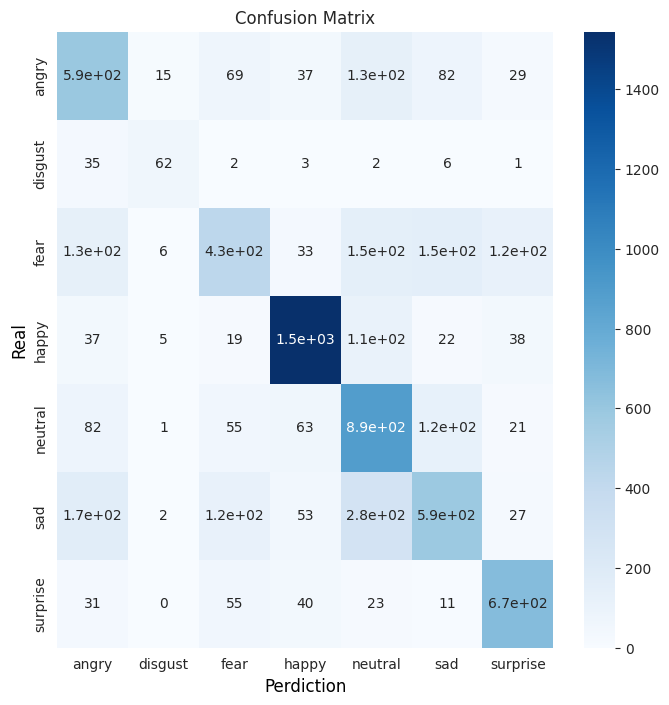

In [211]:
cm = confusion_matrix(y_test_int, predicitions)
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, xticklabels= classes_list, yticklabels=classes_list, cmap='Blues')
plt.xlabel('Perdiction',fontsize = 12, color='black')
plt.ylabel('Real', fontsize = 12, color='black')
plt.title('Confusion Matrix')
plt.show()

# Prediction Vs Real

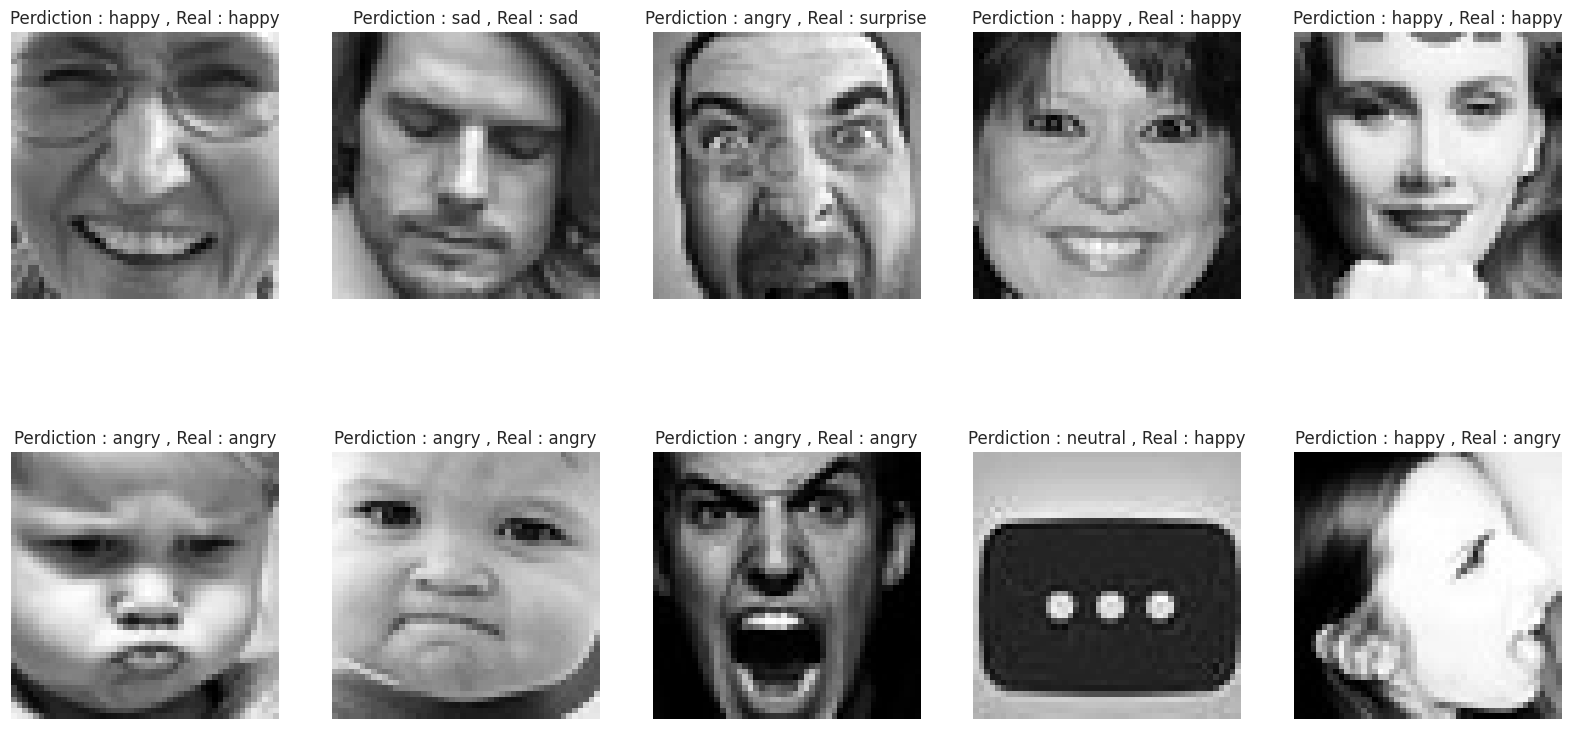

In [183]:
plt.figure(figsize=(20,10))
for i in range(10):
    img_no = np.random.randint(0, X_test.shape[0])
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[img_no],cmap='gray')
    plt.grid('off')
    plt.axis('off')
    plt.title(f'Perdiction : {classes_list[predicitions[img_no]]} , Real : {classes_list[int(y_test_int[img_no])]}')
plt.show()

# -----------------------------------------------------------------------------------   
# -----------------------------------------------------------------------------------   
# -----------------------------------------------------------------------------------   
# -----------------------------------------------------------------------------------   

# Transfer Learning Using **VGG16**

# Reading Images

In [145]:
X_train_vgg16, X_validate_vgg16, y_train_vgg16, y_validate_vgg16 = read_image_from_path('/kaggle/input/fer2013/train', img_dim, False, True)
X_test_vgg16, y_test_vgg16 = read_image_from_path('/kaggle/input/fer2013/test', img_dim, False)

In [146]:
X_train_vgg16.shape, X_validate_vgg16.shape, X_test_vgg16.shape

((21531, 48, 48, 3), (7178, 48, 48, 3), (7178, 48, 48, 3))

In [147]:
y_train_vgg16.shape, y_validate_vgg16.shape, y_test_vgg16.shape

((21531,), (7178,), (7178,))

# Preprocessing

In [148]:
X_train_vgg16 = X_train_vgg16 / 255
X_validate_vgg16 = X_validate_vgg16 / 255
X_test_vgg16 = X_test_vgg16 / 255

X_train_vgg16 = X_train_vgg16.reshape(-1, img_dim, img_dim, 3)
X_validate_vgg16 = X_validate_vgg16.reshape(-1, img_dim, img_dim, 3)
X_test_vgg16 = X_test_vgg16.reshape(-1, img_dim, img_dim, 3)

from tensorflow.keras.utils import to_categorical

y_train_vgg16 = to_categorical(y_train_vgg16, num_classes=7)
y_validate_vgg16 = to_categorical(y_validate_vgg16, num_classes=7)
y_test_vgg16 = to_categorical(y_test_vgg16, num_classes=7)

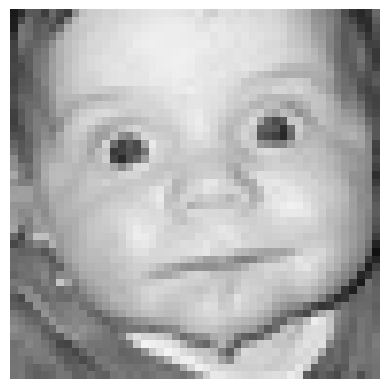

In [149]:
plt.imshow(X_train_vgg16[0]);
plt.grid('off')
plt.axis('off')
plt.show()

## Data Augmentation

In [150]:
train_generator_vgg16 = train_datagen.flow(X_train_vgg16, y_train_vgg16, batch_size=64)

# Implementing Model

In [151]:
# VGG16
base_model = VGG16(weights='imagenet', include_top= False, input_shape=(48,48,3))
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)          │ (None, 48, 48, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 48, 48, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 48, 48, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [152]:
base_model.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

In [153]:
vgg16_model = Sequential()
vgg16_model.add(base_model)
vgg16_model.add(Flatten())

# Dense First Layer
vgg16_model.add(Dense(512, activation='relu'))
vgg16_model.add(BatchNormalization())
vgg16_model.add(Dropout(0.5))

# Dense Second Layer
vgg16_model.add(Dense(256, activation = 'relu'))
vgg16_model.add(BatchNormalization())
vgg16_model.add(Dropout(0.5))

# Output Layer
vgg16_model.add(Dense(7, activation='softmax'))

optimizer = Adam(learning_rate=1e-4)
vgg16_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

vgg16_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 1, 1, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_41               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,113,543 (57.65 MB)

 Trainable params: 7,476,743 (28.52 MB)

 Non-trainable params: 7,636,800 (29.13 MB)

In [154]:
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=15,
                                            factor=0.2,
                                            min_lr=0.0001)

history = vgg16_model.fit(
                    train_generator_vgg16,
                    epochs = 50,
                    validation_data = (X_validate_vgg16, y_validate_vgg16),
                    callbacks = [early_stopping])

Epoch 1/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.1958 - loss: 2.8310 - val_accuracy: 0.1918 - val_loss: 3.6936
Epoch 2/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.3060 - loss: 2.2441 - val_accuracy: 0.2522 - val_loss: 3.0756
Epoch 3/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.3559 - loss: 1.9765 - val_accuracy: 0.4646 - val_loss: 1.5420
Epoch 4/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.3851 - loss: 1.8314 - val_accuracy: 0.4335 - val_loss: 1.6279
Epoch 5/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.4041 - loss: 1.6899 - val_accuracy: 0.4930 - val_loss: 1.3937
Epoch 6/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.4280 - loss: 1.6011 - val_accuracy: 0.4634 - val_loss: 1.5003
Epoch 7/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.4568 - loss: 1.5173 - val_accuracy: 0.4666 - val_loss: 1.3949
Epoch 8/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.4656 - loss: 1.4632 - 

# Evaluation

In [155]:
model_eval = vgg16_model.evaluate(X_test_vgg16, y_test_vgg16)
print("Loss of Model: ", model_eval[0])
print("Accuracy of Model:", round(model_eval[1]*100,2),'%')

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5286 - loss: 1.2317
Loss of Model:  1.2316043376922607
Accuracy of Model: 54.54 %


In [156]:
model_eval = vgg16_model.evaluate(X_train_vgg16, y_train_vgg16)
print("Loss of Model: ", model_eval[0])
print("Accuracy of Model:", round(model_eval[1]*100,2),'%')

673/673 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6312 - loss: 0.9972
Loss of Model:  0.994731068611145
Accuracy of Model: 63.32 %


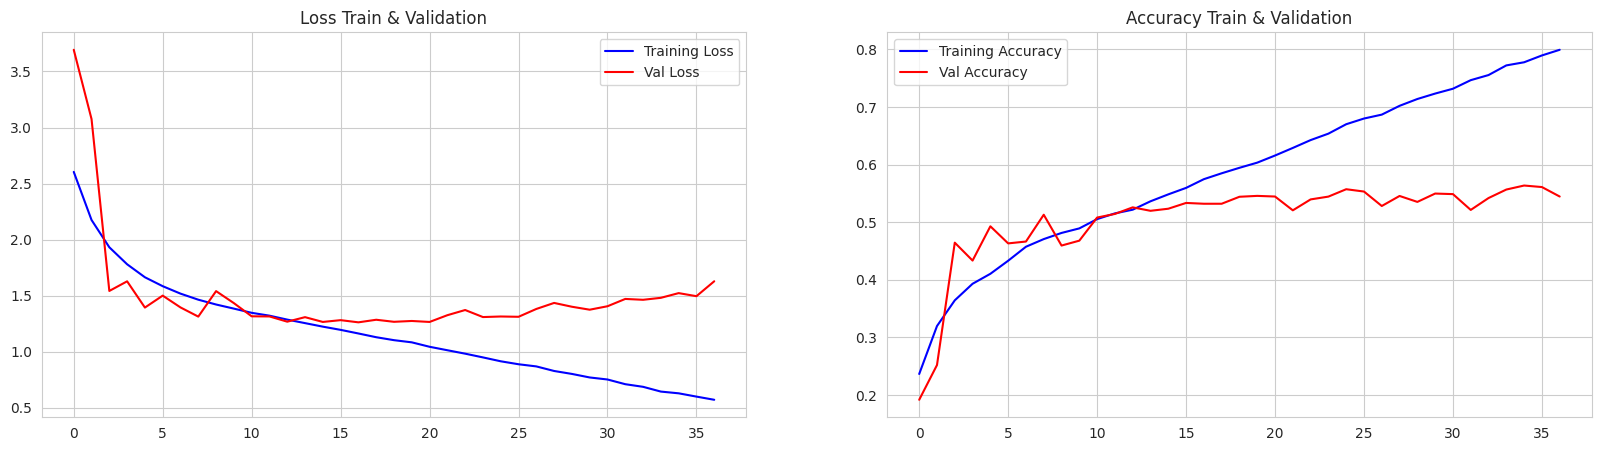

In [157]:
plt.figure(figsize = (20,5))

plt.subplot(1,2,1)
sns.lineplot(x=history.epoch, y=history.history['loss'], color='blue', label='Training Loss')
sns.lineplot(x=history.epoch, y=history.history['val_loss'], color='red', label='Val Loss')
plt.title('Loss Train & Validation')
plt.legend(loc='best')

plt.subplot(1,2,2)
sns.lineplot(x=history.epoch, y=history.history['accuracy'], color='blue', label='Training Accuracy')
sns.lineplot(x=history.epoch, y=history.history['val_accuracy'], color='red', label='Val Accuracy')
plt.title('Accuracy Train & Validation')
plt.legend(loc='best')

plt.show()

In [165]:
vgg16_predicitions = vgg16_model.predict(X_test_vgg16)
y_test_int_vgg16 = np.argmax(y_test_vgg16, axis=1)
vgg16_predicitions = np.argmax(vgg16_predicitions, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [166]:
print(classification_report(y_test_int_vgg16, vgg16_predicitions, target_names=list(classes.keys())))

              precision    recall  f1-score   support

       angry       0.50      0.33      0.40       958
     disgust       0.57      0.07      0.13       111
        fear       0.44      0.32      0.37      1024
       happy       0.81      0.68      0.74      1774
     neutral       0.44      0.64      0.52      1233
         sad       0.42      0.55      0.47      1247
    surprise       0.66      0.70      0.68       831

    accuracy                           0.55      7178
   macro avg       0.55      0.47      0.47      7178
weighted avg       0.56      0.55      0.54      7178



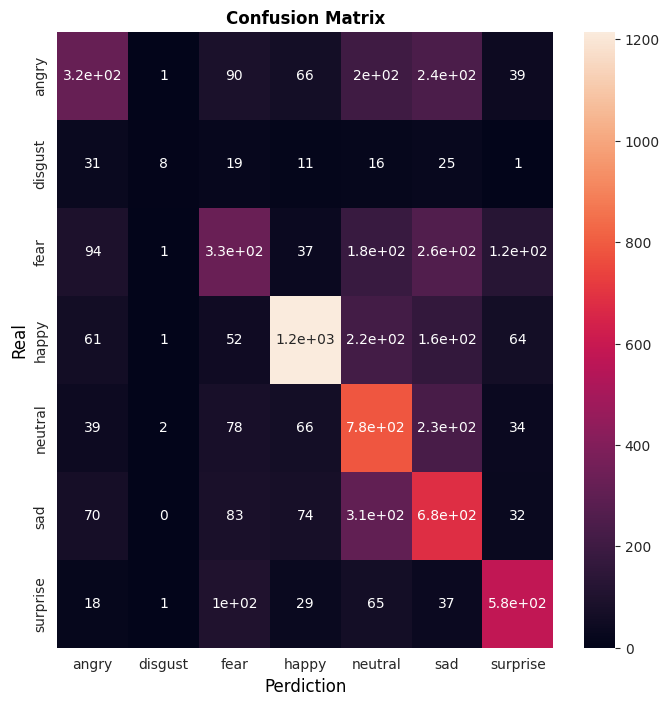

In [212]:
cm = confusion_matrix(y_test_int_vgg16, vgg16_predicitions)
plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, xticklabels= classes_list, yticklabels=classes_list, cmap='rocket')
plt.xlabel('Perdiction',fontsize = 12, color='black')
plt.ylabel('Real', fontsize = 12, color='black')
plt.title('Confusion Matrix', fontweight = 'bold', color='black')
plt.show()

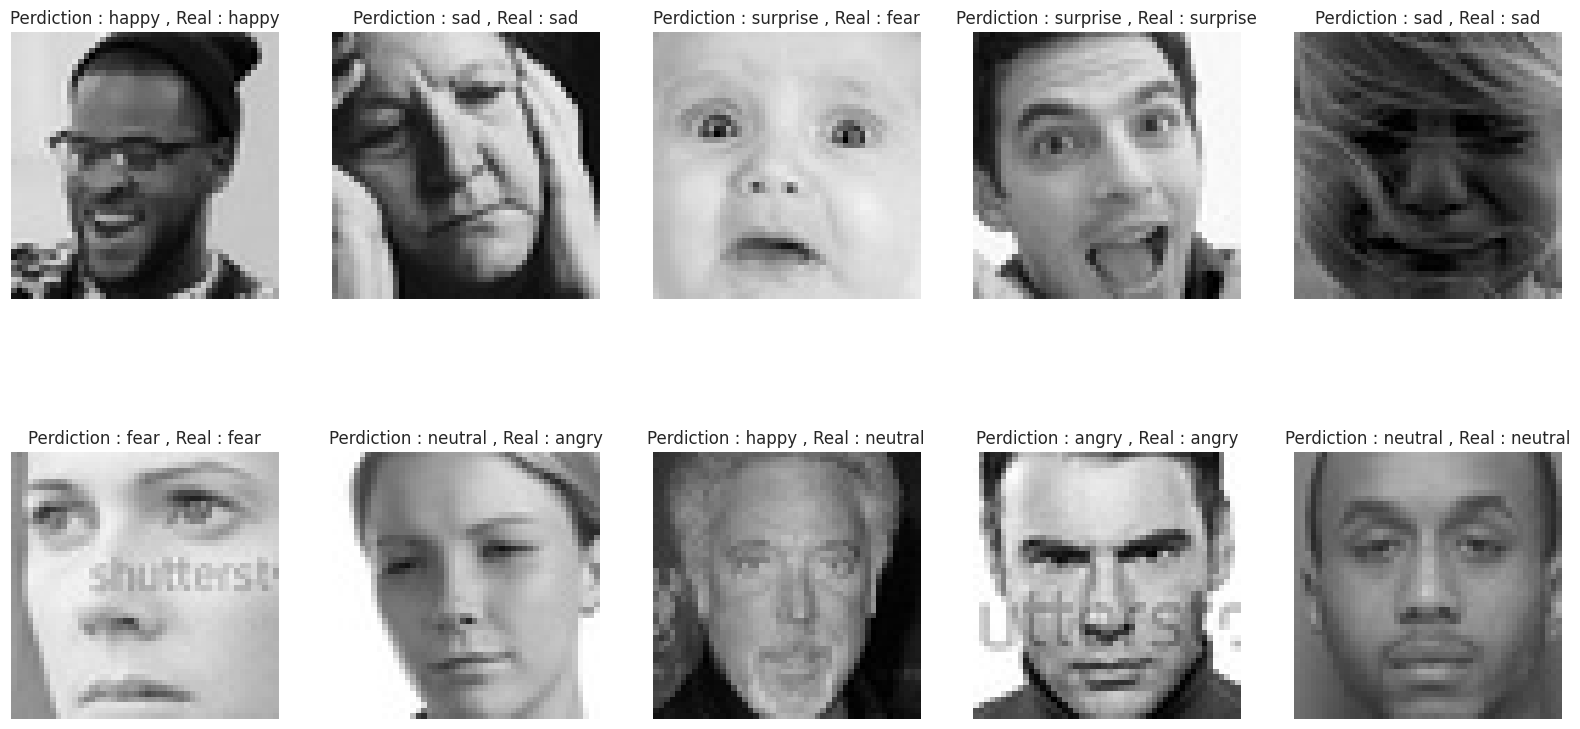

In [168]:
plt.figure(figsize=(20,10))
for i in range(10):
    img_no = np.random.randint(0, X_test_vgg16.shape[0])
    plt.subplot(2,5,i+1)
    plt.imshow(X_test_vgg16[img_no],cmap='gray')
    plt.grid('off')
    plt.axis('off')
    plt.title(f'Perdiction : {classes_list[vgg16_predicitions[img_no]]} , Real : {classes_list[int(y_test_int_vgg16[img_no])]}')
plt.show()

# Comparison Between two Models in Testing

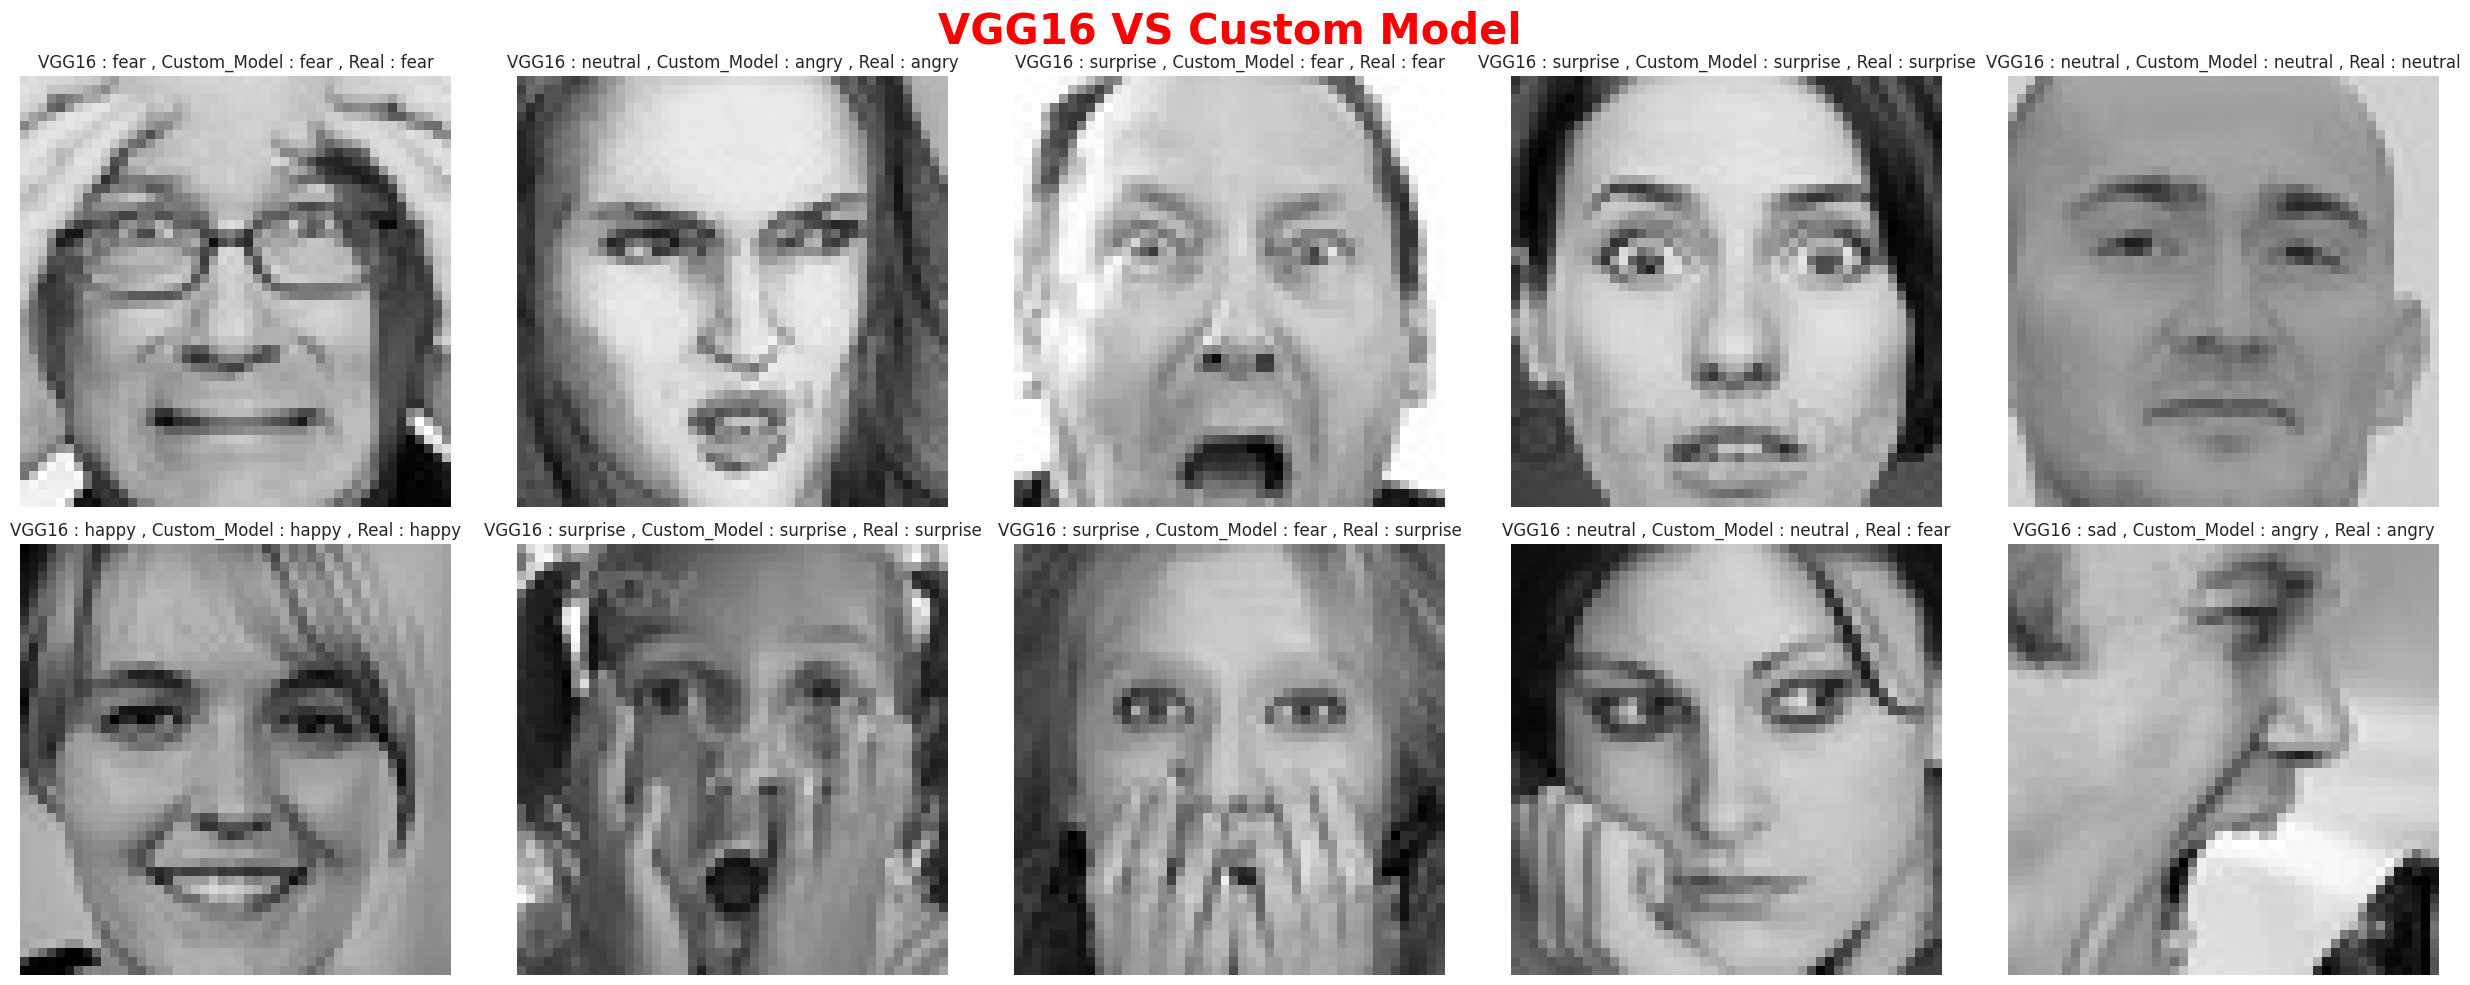

In [209]:
plt.figure(figsize=(25,10))
plt.suptitle('VGG16 VS Custom Model', fontsize = 30, fontweight = 'bold',color='red')
for i in range(10):
    img_no = np.random.randint(0, X_test_vgg16.shape[0])
    plt.subplot(2,5,i+1)
    plt.imshow(X_test_vgg16[img_no],cmap='gray')
    plt.grid('off')
    plt.axis('off')
    plt.title(f'VGG16 : {classes_list[vgg16_predicitions[img_no]]} , Custom_Model : {classes_list[predicitions[img_no]]} , Real : {classes_list[int(y_test_int_vgg16[img_no])]}')
plt.tight_layout(h_pad=2.2)
plt.show()

# Testing on Real Data

In [316]:
# Reading Real Images
def read_real_images(path, img_dim, dim, gray_scale=False):
    X = []

    # Reading Images in Folders
    for file in os.listdir(path):
        if gray_scale:
            image = cv2.imread(path + '/' + file, cv2.IMREAD_GRAYSCALE)
        else:
            image = cv2.imread(path + '/'  + file)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image_array = cv2.resize(image, (img_dim, img_dim))
        X.append(list(image_array))
        
    X = np.array(X)
    X = X / 255
    X = X.reshape(-1, img_dim, img_dim, dim)
    return X

In [328]:
image_custom = read_real_images('/kaggle/input/real-test', img_dim, 1, True)
image_vgg16 = read_real_images('/kaggle/input/real-test', img_dim, 3)

perdiction_custom = model.predict(image_custom)
perdiction_custom = np.argmax(perdiction_custom, axis=1)

perdiction_vgg16 = vgg16_model.predict(image_vgg16)
perdiction_vgg16 = np.argmax(perdiction_vgg16, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


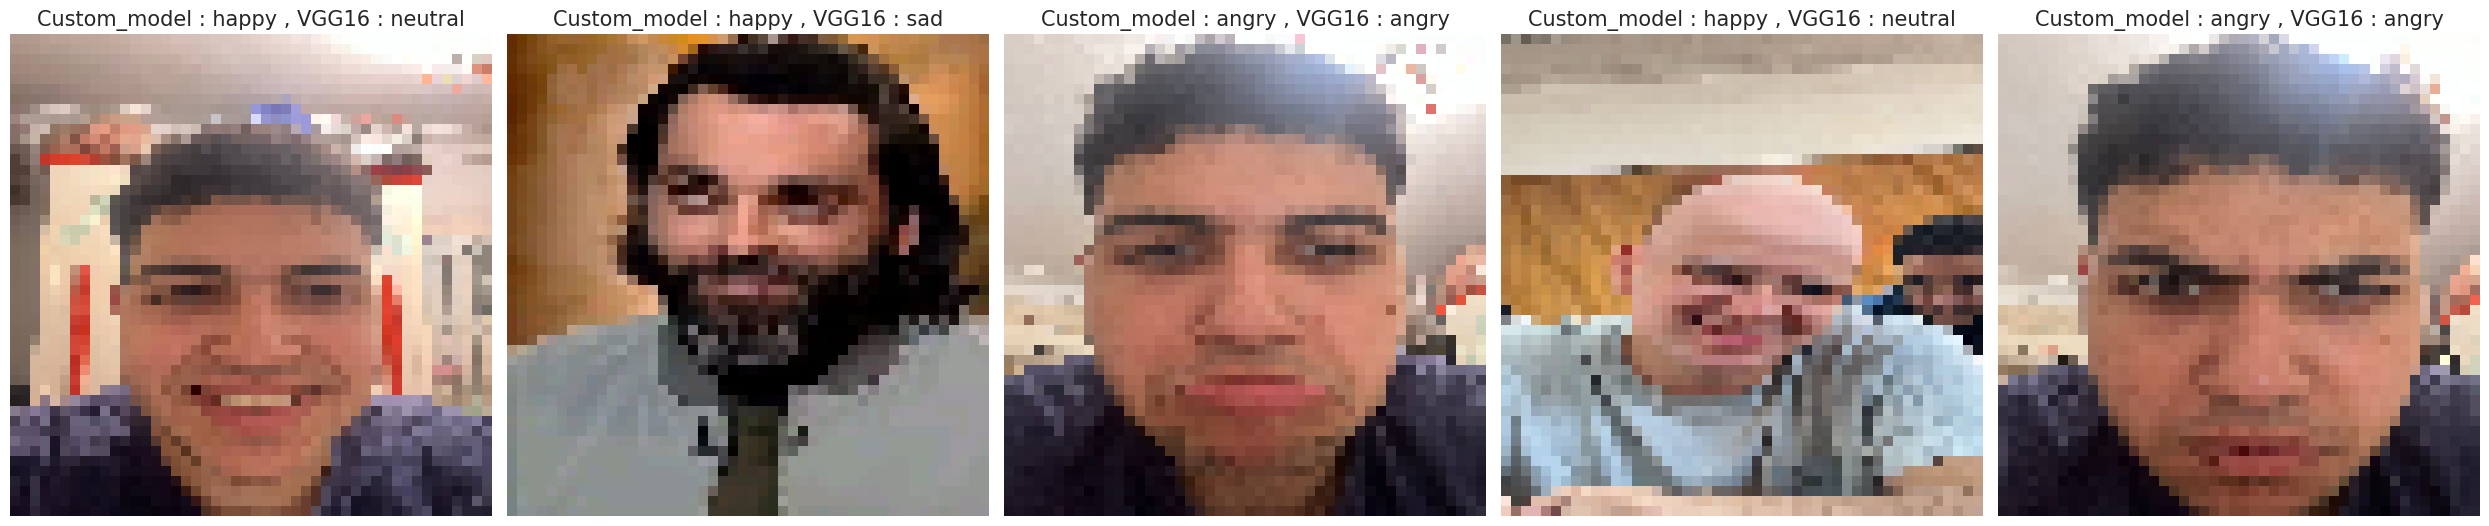

In [335]:
plt.figure(figsize=(25,10))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(image_vgg16[i],cmap='gray')
    plt.axis('off')
    plt.title(f'Custom_model : {classes_list[perdiction_custom[i]]} , VGG16 : {classes_list[perdiction_vgg16[i]]}', fontsize=15)
plt.tight_layout(h_pad=2.2)
plt.show()